In [1]:
from src.data_loader import load_data
from src.preprocess import prepare_data, print_vectorized_sample
from src.ML.train_NN import train_model, print_NN_input_sample, TextClassifier, DeepTextClassifier, train_model_sample_weights, train_model_class_weights_and_sampling

#from src.analysis import  intra_category_similarity
from src.plotting import plot_confusion_matrix, plot_learning_curve, plot_metrics_bar_chart
#from src.ML.train_svm import train_SVM
#from src.ML.train_rf import train_random_forest

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
plt.rcParams["figure.figsize"] = (3,2)


DATA_PATH = "/home/xkubanova_126831/bakalarka/nbs_binary/data/ekosentiment_titles_binary.csv"

In [2]:
print("--- 1. Loading and Preparing Data ---")
df = load_data(DATA_PATH)

--- 1. Loading and Preparing Data ---
Dataset shape: (694, 2)

Categories samples:

0:
  Príjmy vedúcich policajných funkcionárov A verejnosť tak mohla o celkových príjmoch policajnej elity u nás iba špekulovať. Jeho príjem za vlaňajšok v celkovej výške takmer 44-tisíc eur totiž prekonal viceprezident polície Ľubomír Ábel. Príjmy vedúcich policajných funkcionárov...

1:
  Analytik o osobných bankrotoch: Ich pravidlá sú podľa neho nastavené veľmi voľne "Obávam sa, že toto nastavenie bude do budúcnosti motivovať časť ľudí, aby sa nadmerne zadlžovala a následne využila osobný bankrot a začala bez dlhov. "Od štátu by som čakal také nastavenie legislatívy, ktoré ľudí navedie k právnemu a finančnému poradenstvu a riešeniu dlhov v rannej fáze problému. Búlik z OVB je pres...


Simple Feed Forward NN
Class weights: tensor([0.6869, 3.6755], device='cuda:0')

Classification Report:
              precision    recall  f1-score   support

           0     0.8218    0.8218    0.8218       101
           1     0.5263    0.5263    0.5263        38

    accuracy                         0.7410       139
   macro avg     0.6740    0.6740    0.6740       139
weighted avg     0.7410    0.7410    0.7410       139

Final Test Accuracy: 0.7410


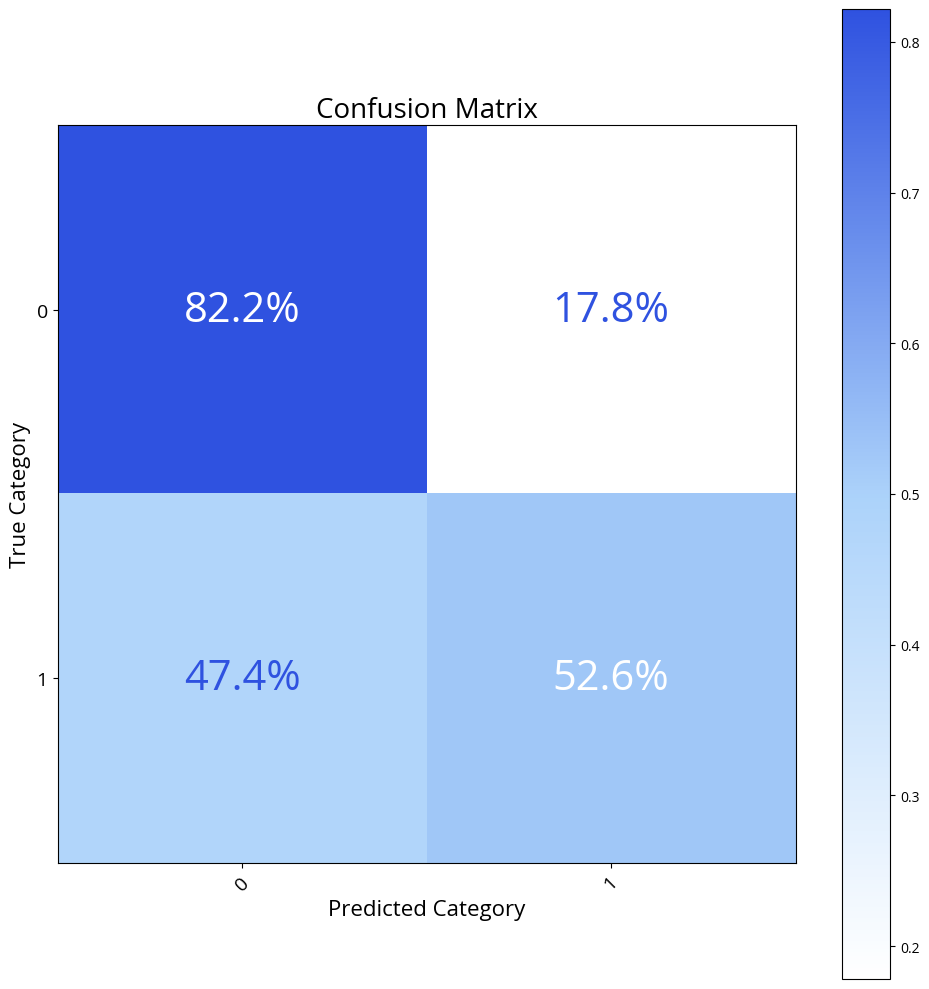

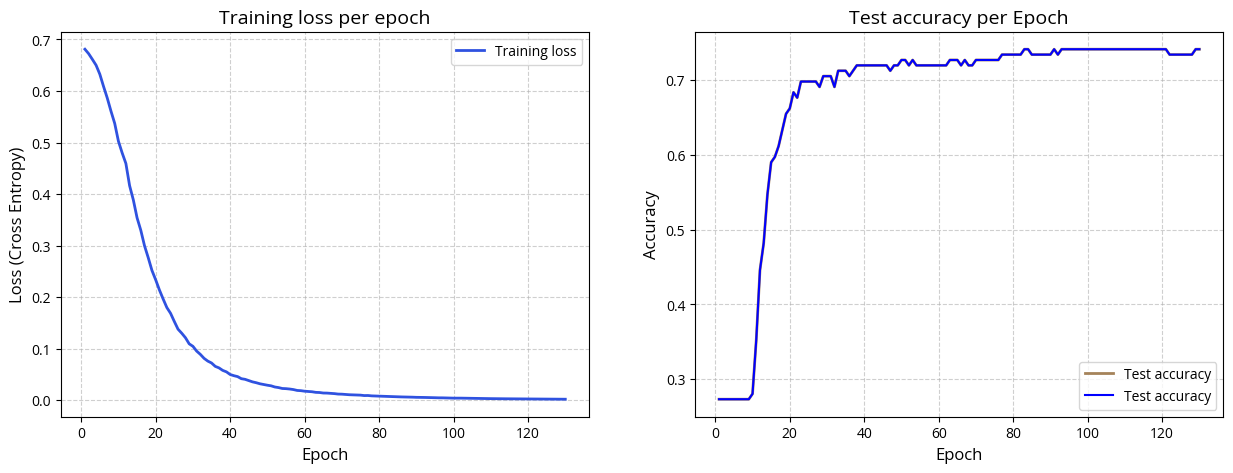

<Figure size 300x200 with 0 Axes>

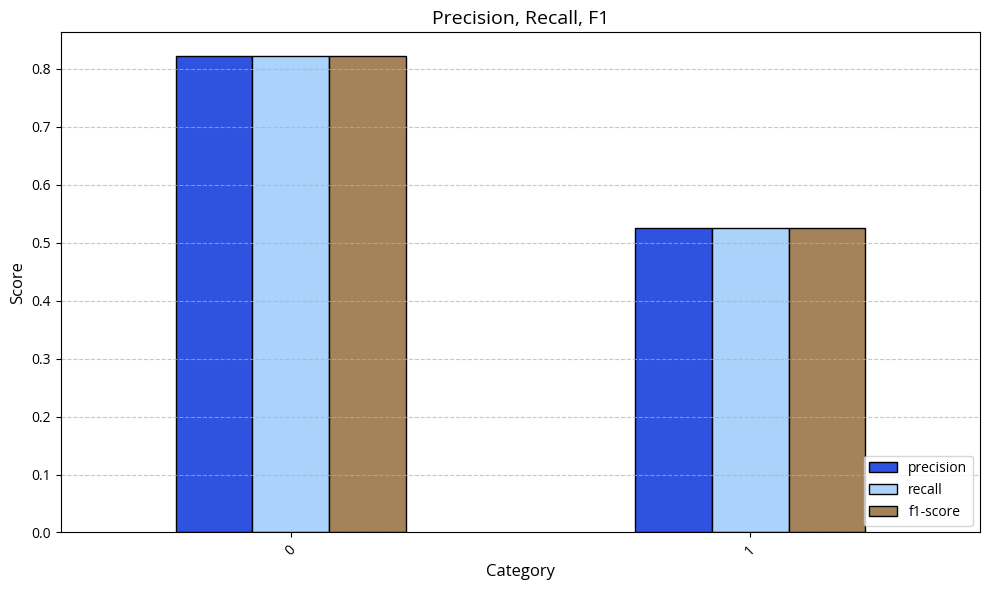

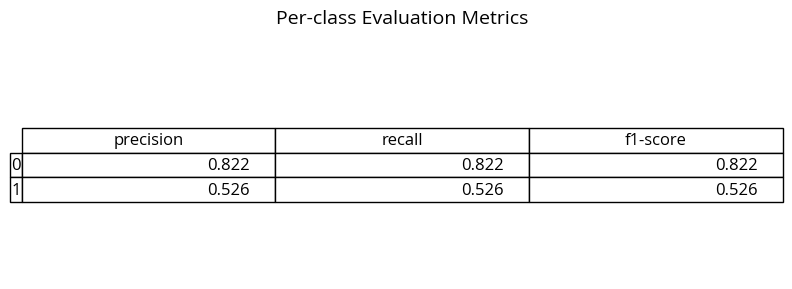

Input dimension for NN: 3000


In [3]:
from src.ML.train_NN import TextClassifier

#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Simple Feed Forward NN")

simple_model, class_to_idx, simple_acc = train_model(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 256},
    epochs=130,
    lr=0.0001
)
print("Input dimension for NN:", X_train.shape[1])

Deep Feed Forward NN
Class weights: tensor([0.6869, 3.6755], device='cuda:0')

Classification Report:
              precision    recall  f1-score   support

           0     0.8300    0.8218    0.8259       101
           1     0.5385    0.5526    0.5455        38

    accuracy                         0.7482       139
   macro avg     0.6842    0.6872    0.6857       139
weighted avg     0.7503    0.7482    0.7492       139

Final Test Accuracy: 0.7482


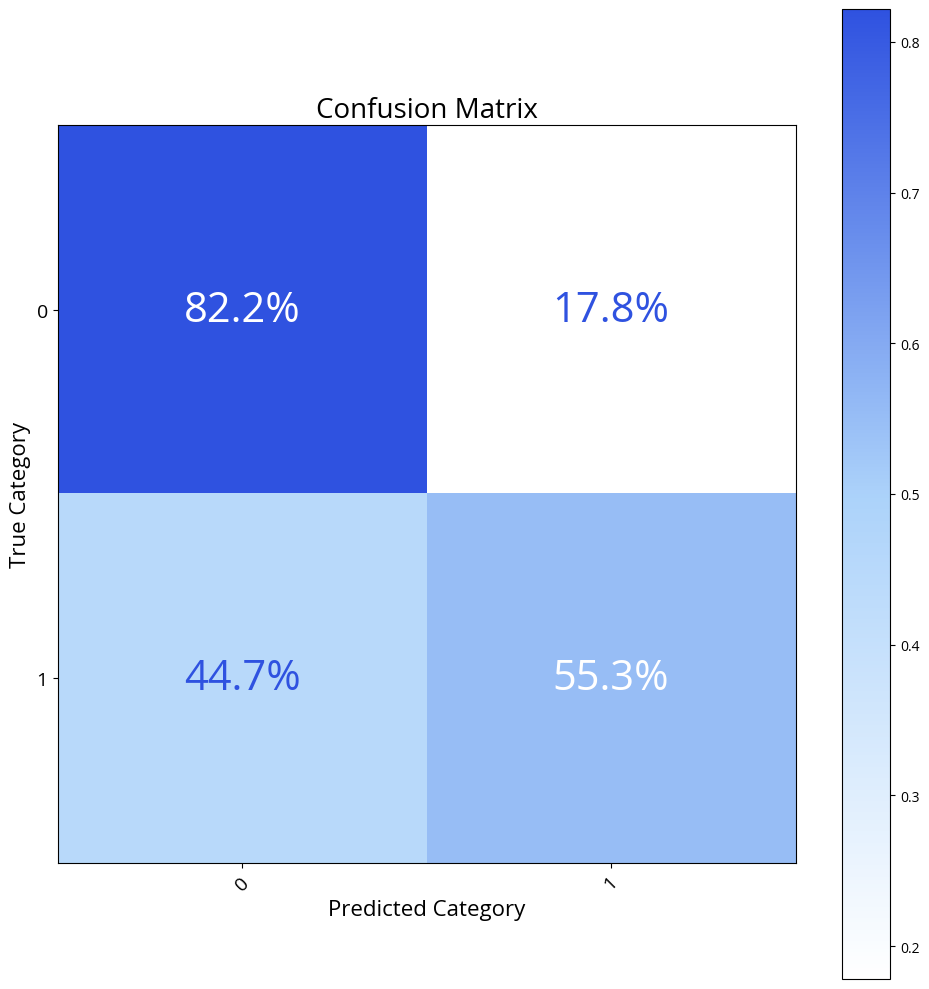

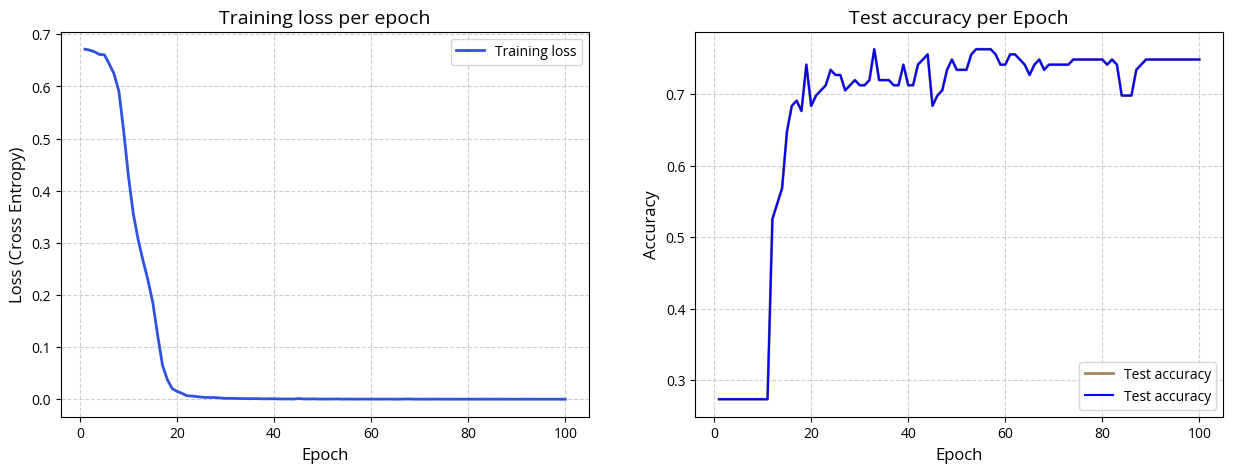

<Figure size 300x200 with 0 Axes>

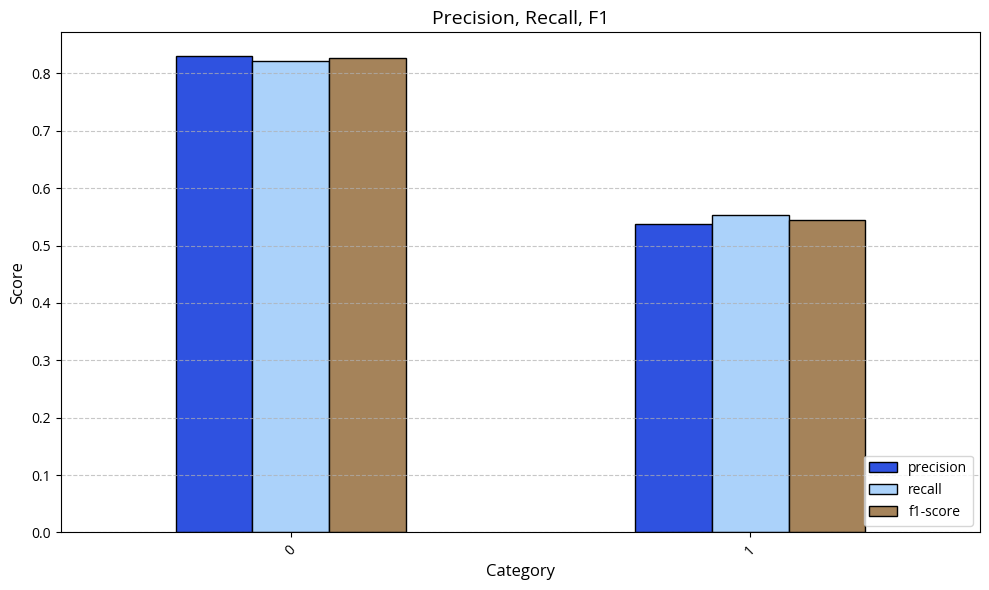

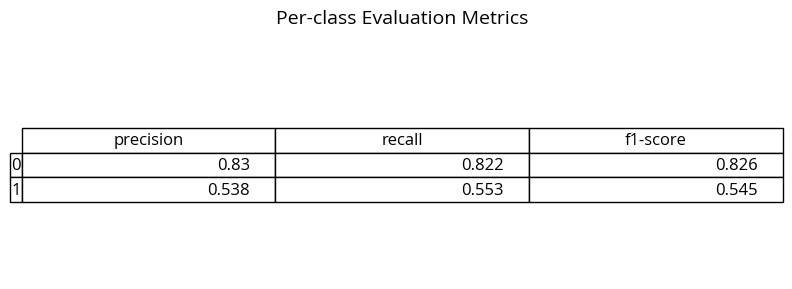

In [4]:
from src.ML.train_NN import DeepTextClassifier

#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Deep Feed Forward NN")

deep_model, class_to_idx, deep_acc = train_model(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [256, 128, 64, 32]},
    epochs=100,
    lr=0.0001
)


Simple Feed Forward NN

Classification Report:
              precision    recall  f1-score   support

           0     0.8036    0.8911    0.8451       101
           1     0.5926    0.4211    0.4923        38

    accuracy                         0.7626       139
   macro avg     0.6981    0.6561    0.6687       139
weighted avg     0.7459    0.7626    0.7486       139

Final Test Accuracy: 0.7626


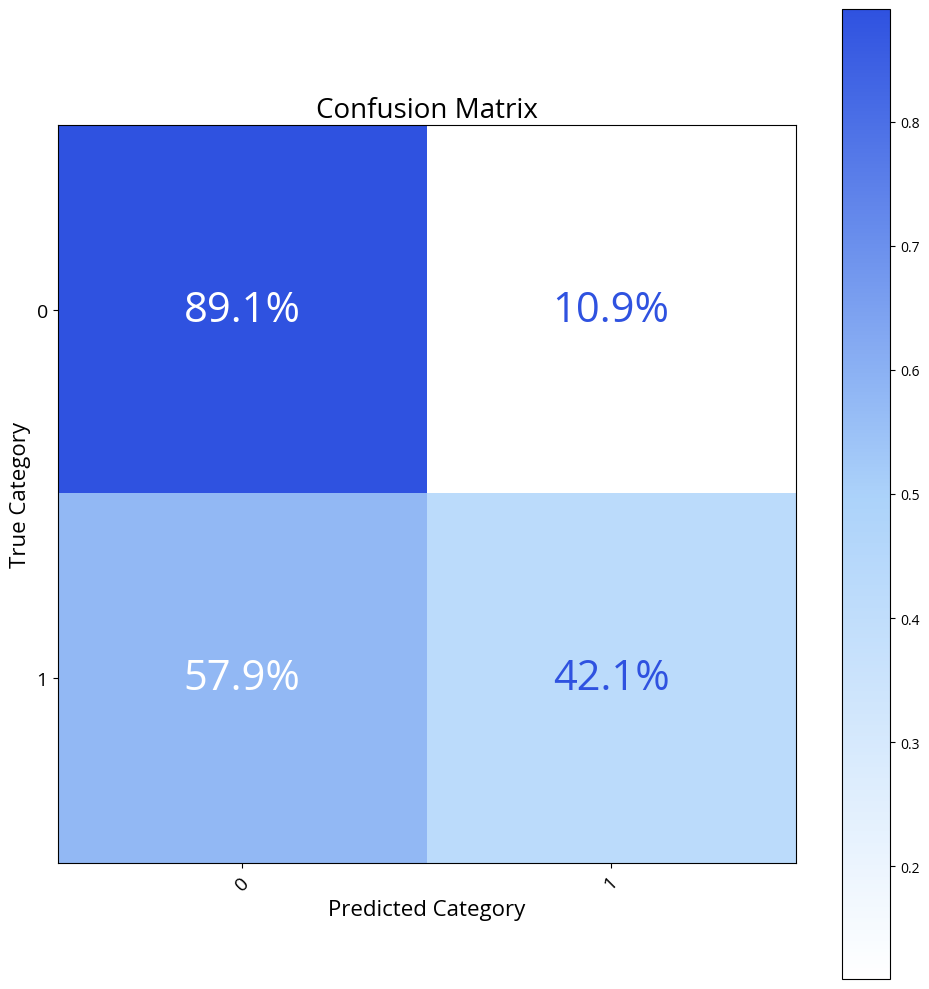

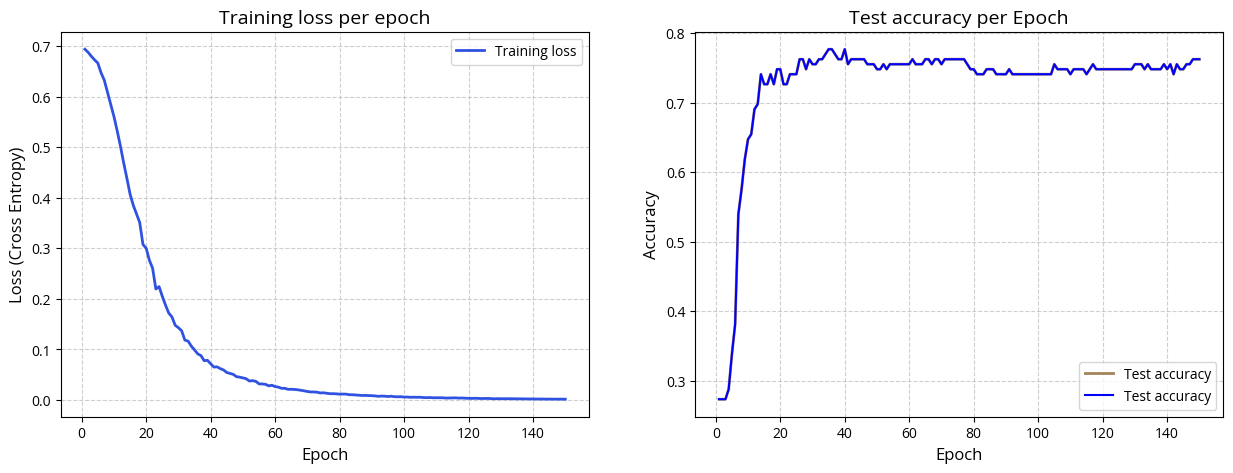

<Figure size 300x200 with 0 Axes>

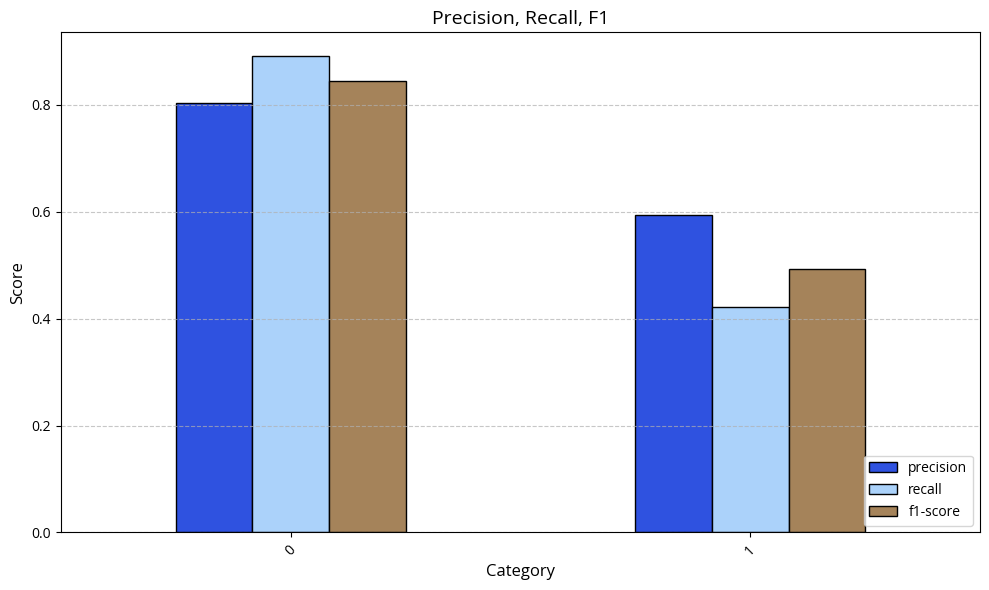

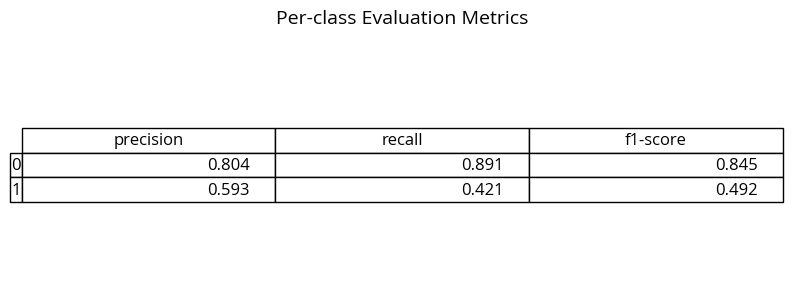

In [5]:
from src.ML.train_NN import TextClassifier

#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Simple Feed Forward NN")

simple_model, class_to_idx, simple_acc = train_model_sample_weights(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 256},
    epochs=150,
    lr=0.00008
)


Deep Feed Forward NN

Classification Report:
              precision    recall  f1-score   support

           0     0.7876    0.8812    0.8318       101
           1     0.5385    0.3684    0.4375        38

    accuracy                         0.7410       139
   macro avg     0.6630    0.6248    0.6346       139
weighted avg     0.7195    0.7410    0.7240       139

Final Test Accuracy: 0.7410


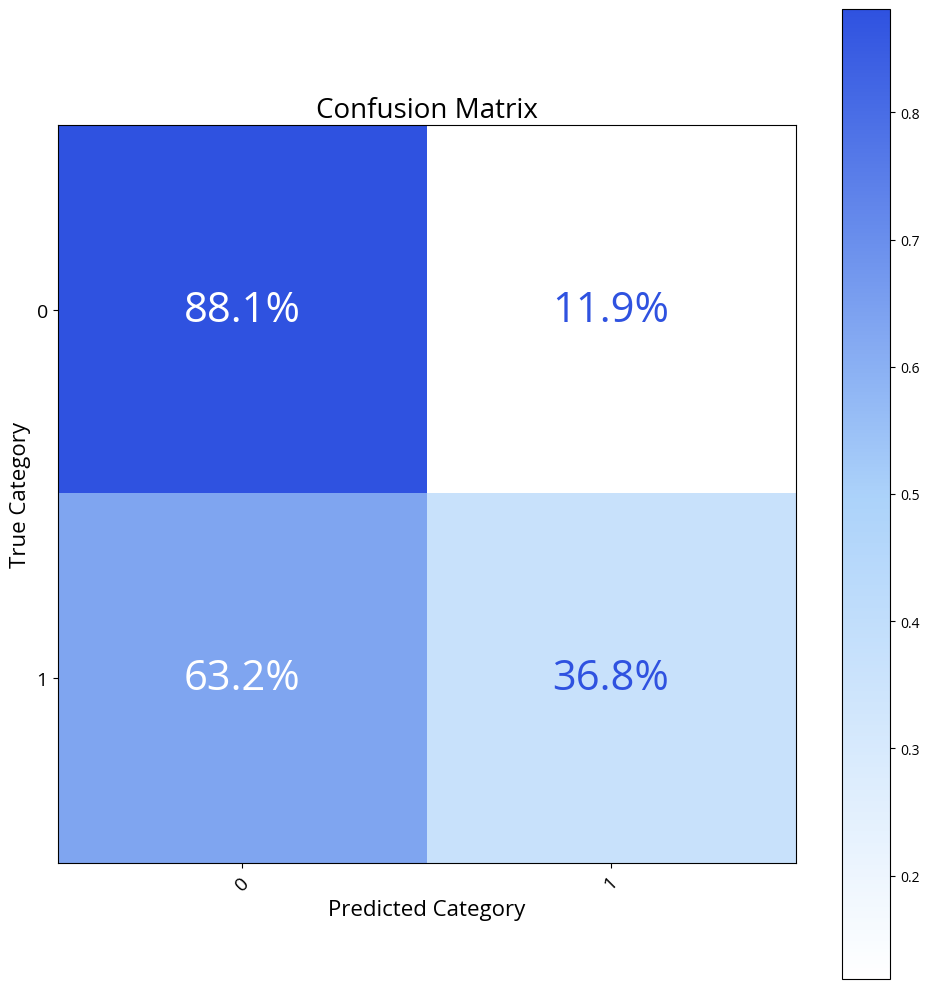

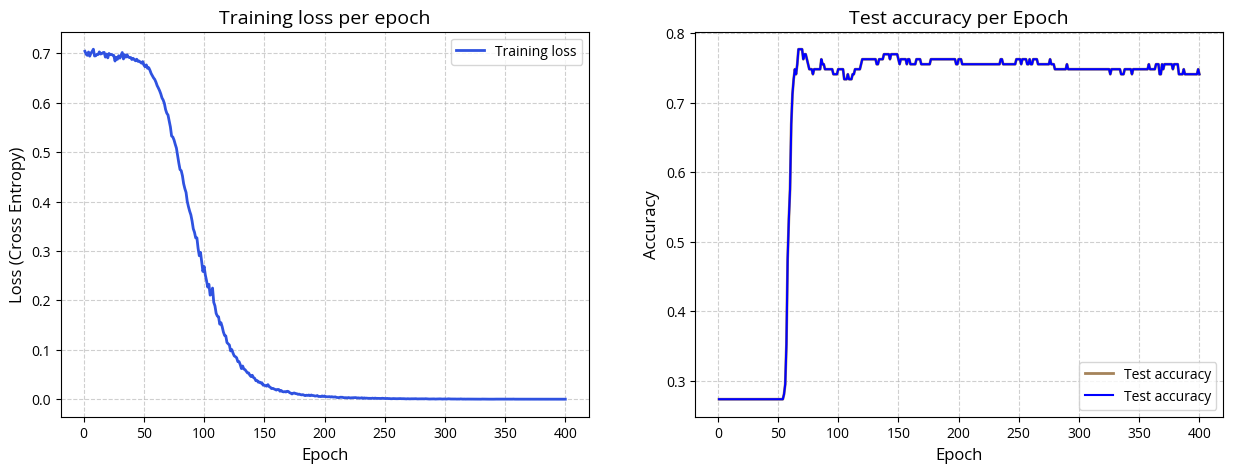

<Figure size 300x200 with 0 Axes>

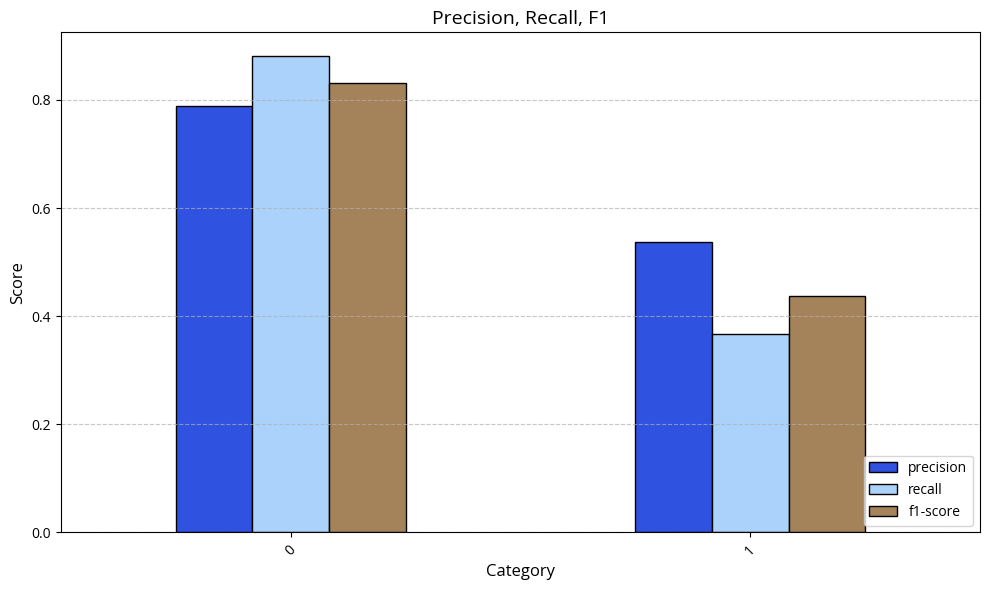

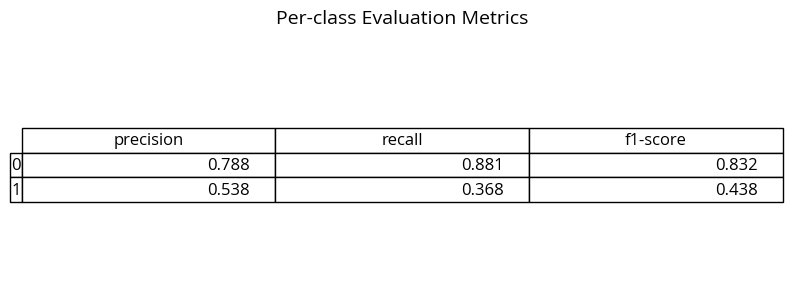

In [6]:
from src.ML.train_NN import DeepTextClassifier

#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Deep Feed Forward NN")

deep_model, class_to_idx, deep_acc = train_model_sample_weights(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [256, 128, 64, 32]},
    epochs=400,
    lr=0.00001
)


Simple Feed Forward NN
Class weights: tensor([0.6869, 3.6755], device='cuda:0')

Classification Report:
              precision    recall  f1-score   support

           0     0.8235    0.8317    0.8276       101
           1     0.5405    0.5263    0.5333        38

    accuracy                         0.7482       139
   macro avg     0.6820    0.6790    0.6805       139
weighted avg     0.7462    0.7482    0.7471       139

Final Test Accuracy: 0.7482


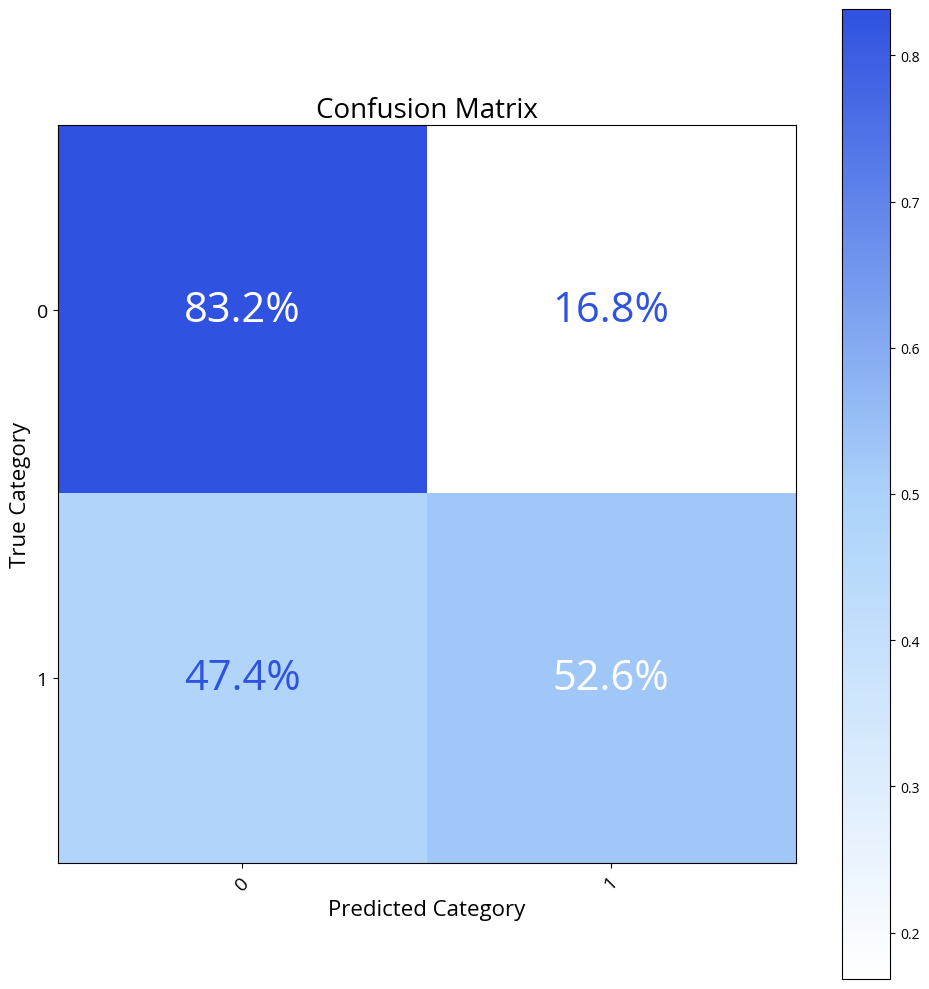

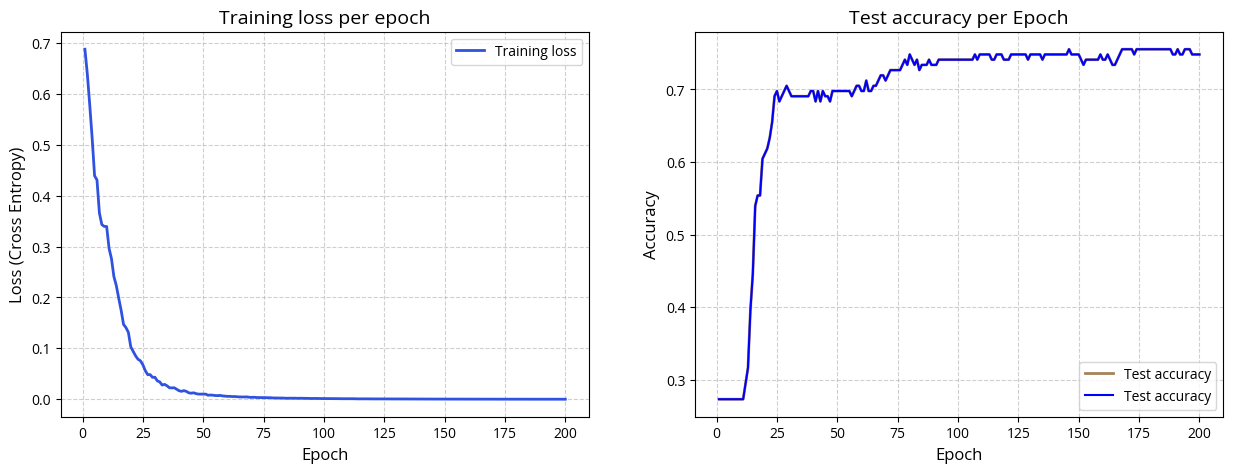

<Figure size 300x200 with 0 Axes>

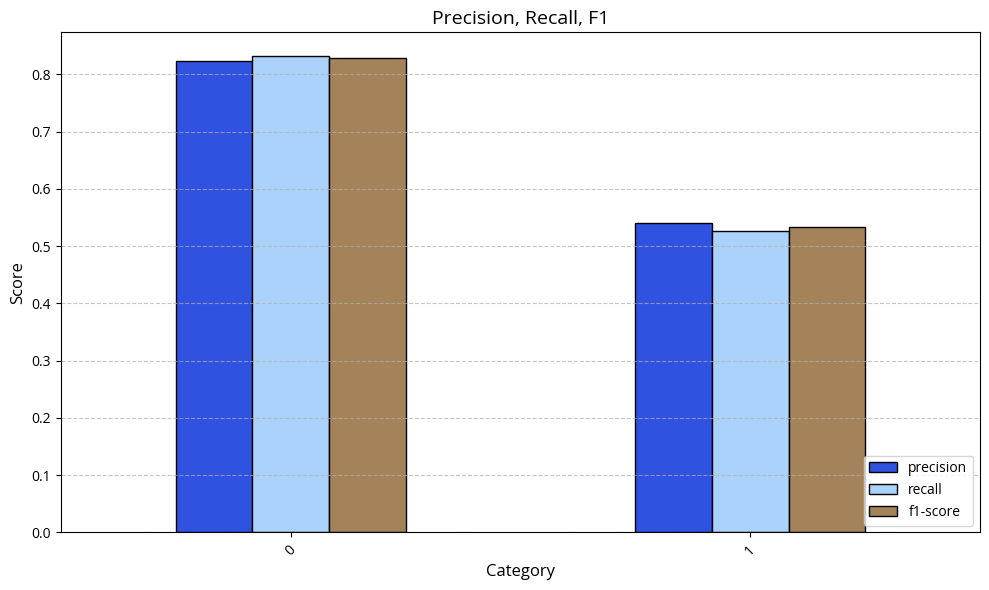

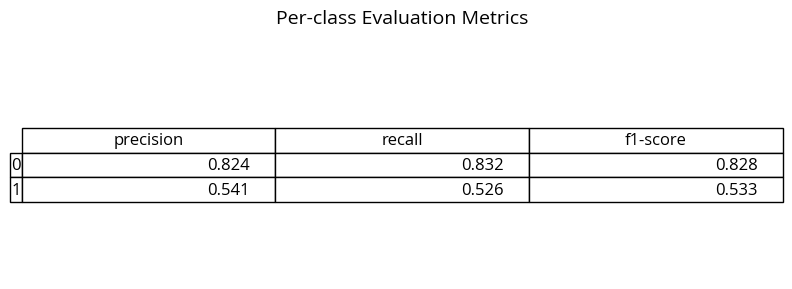

In [7]:
from src.ML.train_NN import TextClassifier

#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Simple Feed Forward NN")

simple_model, class_to_idx, simple_acc = train_model_class_weights_and_sampling(
    X_train, y_train, X_test, y_test,
    model_class=TextClassifier,
    model_params={"hidden_dim": 512},
    epochs=200,
    lr=0.0001
)


Deep Feed Forward NN
Class weights: tensor([0.6869, 3.6755], device='cuda:0')

Classification Report:
              precision    recall  f1-score   support

           0     0.8889    0.7129    0.7912       101
           1     0.5000    0.7632    0.6042        38

    accuracy                         0.7266       139
   macro avg     0.6944    0.7380    0.6977       139
weighted avg     0.7826    0.7266    0.7401       139

Final Test Accuracy: 0.7266


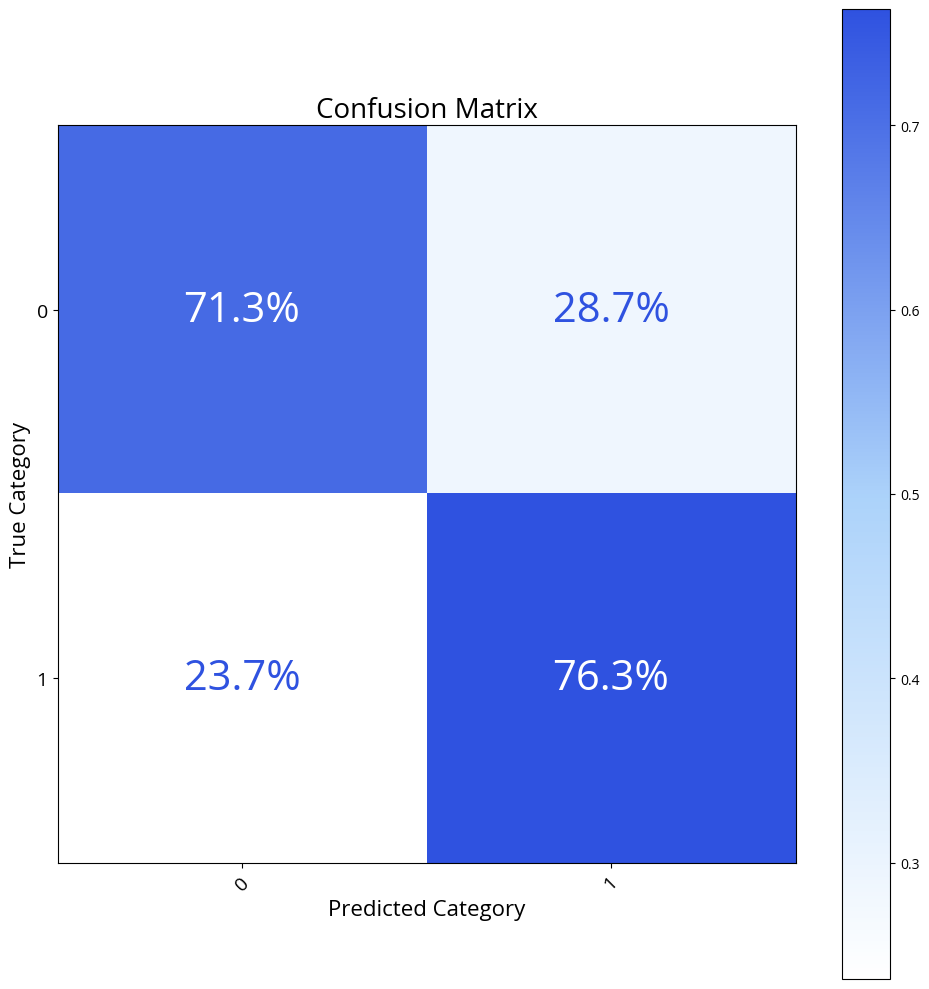

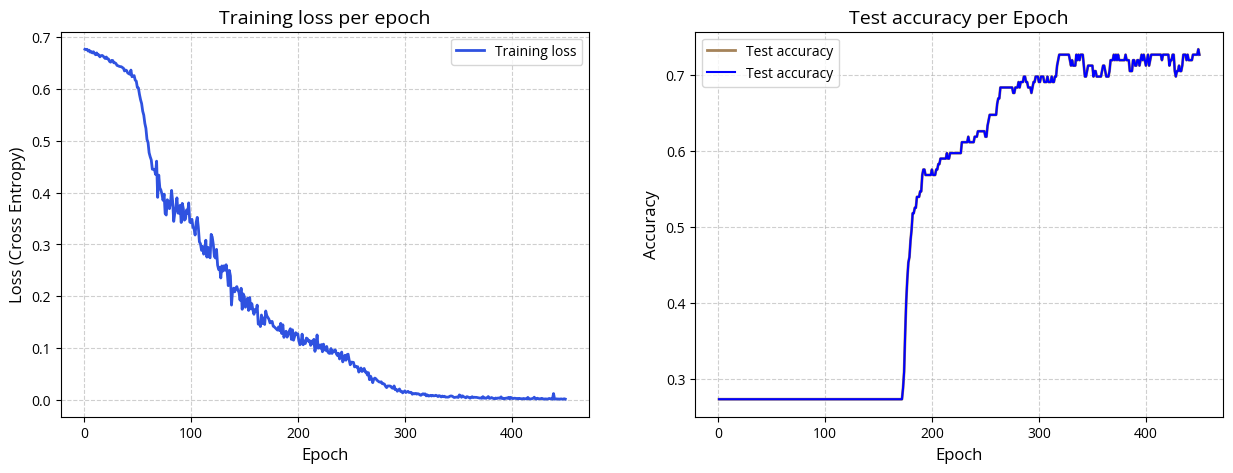

<Figure size 300x200 with 0 Axes>

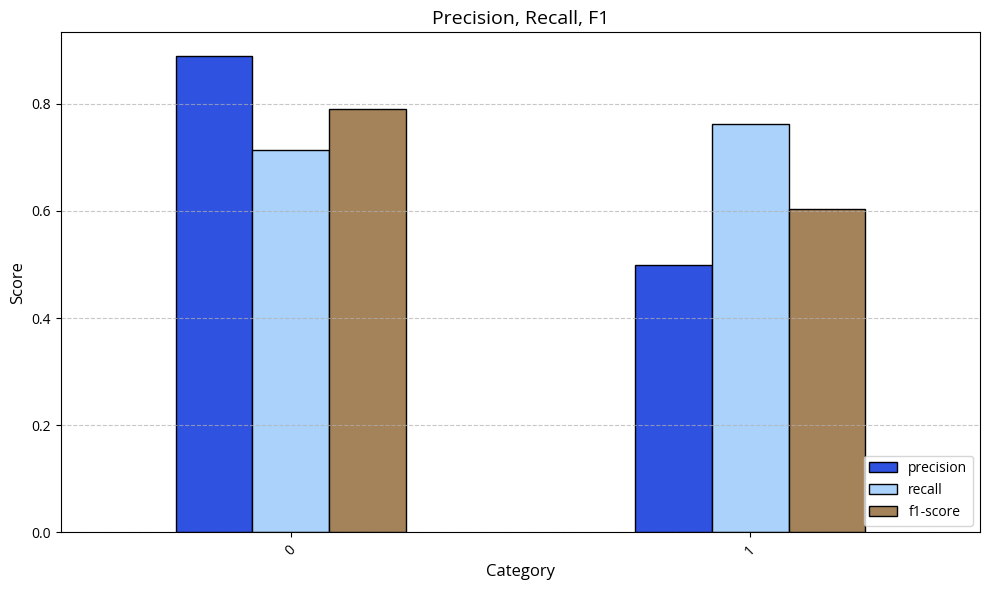

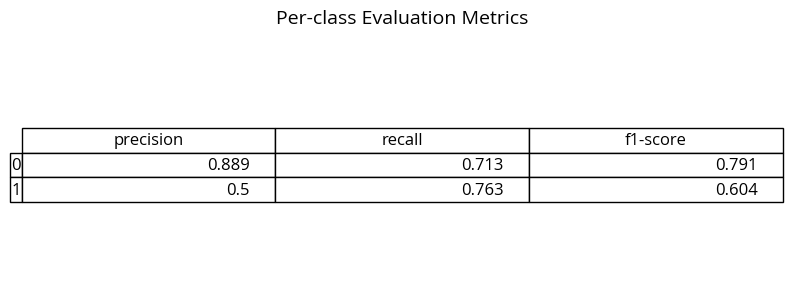

In [8]:
from src.ML.train_NN import DeepTextClassifier

#prepare data
X_train, X_test, y_train, y_test, vectorizer = prepare_data(df)

print("Deep Feed Forward NN")

deep_model, class_to_idx, deep_acc = train_model_class_weights_and_sampling(
    X_train, y_train, X_test, y_test,
    model_class=DeepTextClassifier,
    model_params={"hidden_dims": [256, 128, 64, 32, 16]},
    epochs=450,
    lr=0.00001
)
